In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import re

plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 10})

plt.rcParams["legend.frameon"] = False

In [185]:
def parse_data(target_loop_idx, params, 
               type_to_report = 'inner', 
               report_params=['volume_density'],
              metric='obs'):
    master_data = []
    ftags=[]

    for i, row in params.iterrows():
        f = os.path.join(basedir, params.loc[i, 'result_file'])
        basename = os.path.basename(f).replace('.tsv', '')
        row_dict = {}
    
        df = pd.read_csv(f, sep='\t')

        if type_to_report == 'inner':
            loop_row = df[df['MM'] == 'inner'].iloc[target_loop_idx]
            print(df[df['MM'] == 'inner'])
        elif type_to_report == 'EP':
            loop_row = df[df['loop_type'] == 'EP'].iloc[target_loop_idx]
        elif type_to_report == 'outer':
            loop_row = df[df['MM'] == 'outer'].iloc[target_loop_idx]
            print(df[df['MM'] == 'outer'])
        elif type_to_report == 'CTCF_conv':
            loop_row = df[df['loop_type'] == 'CTCF_conv'].iloc[target_loop_idx]
            if pd.notna(loop_row['MM']):
                print("Warning")
        elif type_to_report == 'CTCF_other':
            loop_row = df[df['loop_type'] == 'CTCF_other'].iloc[target_loop_idx]
            print(loop_row)
        
        row_dict['mean'] = loop_row[f'{metric}_mean']
        row_dict['se'] = loop_row[f'{metric}_se']
        master_data.append(row_dict)
        
        param_string=""
        for k in range(len(report_params)):
            param_string = f"{param_string}{params.loc[i, report_params[k]]}_"
        ftags.append(param_string)

    master_df = pd.DataFrame(master_data)
    master_df.index = ftags    
    
    return master_df, ftags


def error_propagate_se(df, idx_control):
    error_sq = (master_df['se']/master_df['mean'])**2
    const_err = (master_df['se'].loc[idx_control]/master_df['mean'].loc[idx_control])**2
    print(const_err)
    fc_se = np.sqrt(error_sq.values + const_err)
    
    return fc_se

In [195]:
basedir = "/mnt/md1/varshini/Blood/sim_density_processed_v2"
params = pd.read_csv(os.path.join(basedir, "mapping.tsv"), sep="\t").replace(np.nan, 0)
params['volume_density'] =params['volume_density'].replace(0, 0.3)


In [196]:
#select = params[params['vel_steps']=='(0.0025, 50)']
#select = select[~select["original_path"].str.contains("/mnt/md1/varshini/Blood/sim_data_velocity/2026-04-26 17:37:59.846865")]

In [197]:
params

,run_id,sim_id,original_path,result_file,parameters_file,processivity,separations,ctcf_boost_factor,llp,h,loading_width,cohesins_per_mm,volume_density,vel_steps
0,run_000,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_000_sim_00_loops.tsv,run_000_sim_00_parameters.txt,300,240,4,2,0.4,16,64.0,0.15,"(0.0025, 50)"
1,run_000,sim_01,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_000_sim_01_loops.tsv,run_000_sim_01_parameters.txt,300,240,4,2,0.4,16,64.0,0.45,"(0.0025, 50)"
2,run_002,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_002_sim_00_loops.tsv,run_002_sim_00_parameters.txt,300,240,4,2,0.4,16,64.0,0.15,"(0.0025, 50)"
3,run_002,sim_01,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_002_sim_01_loops.tsv,run_002_sim_01_parameters.txt,300,240,4,2,0.4,16,64.0,0.45,"(0.0025, 50)"
4,run_002,sim_02,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_002_sim_02_loops.tsv,run_002_sim_02_parameters.txt,300,240,4,2,0.4,16,64.0,0.60,"(0.0025, 50)"
5,run_003,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_003_sim_00_loops.tsv,run_003_sim_00_parameters.txt,300,240,4,2,0.4,16,0.0,0.60,"(0.0025, 50)"
6,run_004,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_004_sim_00_loops.tsv,run_004_sim_00_parameters.txt,300,240,4,2,0.4,2,256.0,0.30,"(0.0025, 50)"
7,run_007,sim_00,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_00_loops.tsv,run_007_sim_00_parameters.txt,300,240,4,2,0.4,16,32.0,0.30,"(0.0025, 50)"
8,run_007,sim_01,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_01_loops.tsv,run_007_sim_01_parameters.txt,300,240,4,2,0.4,32,32.0,0.30,"(0.0025, 50)"
9,run_007,sim_02,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_02_loops.tsv,run_007_sim_02_parameters.txt,300,240,4,2,0.4,4,32.0,0.30,"(0.0025, 50)"


In [198]:
def error_propagate_se(df, idx_control):
    error_sq = (master_df['se']/master_df['mean'])**2
    const_err = (master_df['se'].iloc[idx_control]/master_df['mean'].iloc[idx_control])**2
    fc_se = np.sqrt(error_sq.values + const_err)
    
    return fc_se

In [199]:
params

,run_id,sim_id,original_path,result_file,parameters_file,processivity,separations,ctcf_boost_factor,llp,h,loading_width,cohesins_per_mm,volume_density,vel_steps
0,run_000,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_000_sim_00_loops.tsv,run_000_sim_00_parameters.txt,300,240,4,2,0.4,16,64.0,0.15,"(0.0025, 50)"
1,run_000,sim_01,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_000_sim_01_loops.tsv,run_000_sim_01_parameters.txt,300,240,4,2,0.4,16,64.0,0.45,"(0.0025, 50)"
2,run_002,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_002_sim_00_loops.tsv,run_002_sim_00_parameters.txt,300,240,4,2,0.4,16,64.0,0.15,"(0.0025, 50)"
3,run_002,sim_01,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_002_sim_01_loops.tsv,run_002_sim_01_parameters.txt,300,240,4,2,0.4,16,64.0,0.45,"(0.0025, 50)"
4,run_002,sim_02,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_002_sim_02_loops.tsv,run_002_sim_02_parameters.txt,300,240,4,2,0.4,16,64.0,0.60,"(0.0025, 50)"
5,run_003,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_003_sim_00_loops.tsv,run_003_sim_00_parameters.txt,300,240,4,2,0.4,16,0.0,0.60,"(0.0025, 50)"
6,run_004,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_004_sim_00_loops.tsv,run_004_sim_00_parameters.txt,300,240,4,2,0.4,2,256.0,0.30,"(0.0025, 50)"
7,run_007,sim_00,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_00_loops.tsv,run_007_sim_00_parameters.txt,300,240,4,2,0.4,16,32.0,0.30,"(0.0025, 50)"
8,run_007,sim_01,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_01_loops.tsv,run_007_sim_01_parameters.txt,300,240,4,2,0.4,32,32.0,0.30,"(0.0025, 50)"
9,run_007,sim_02,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_02_loops.tsv,run_007_sim_02_parameters.txt,300,240,4,2,0.4,4,32.0,0.30,"(0.0025, 50)"


In [202]:
select = params[((params['cohesins_per_mm']==64) | (params['cohesins_per_mm']==0)) &
               (params['volume_density']==0.3)]
#select = params.copy()

Unnamed: 0            30
left                 200
right                330
loop_type     CTCF_other
MM                   NaN
loop_idx              30
obs_mean        0.102641
obs_se          0.001552
oe_mean         3.637603
oe_se           0.055775
Name: 30, dtype: object
Unnamed: 0            30
left                 200
right                330
loop_type     CTCF_other
MM                   NaN
loop_idx              30
obs_mean        0.086147
obs_se           0.00115
oe_mean          3.10604
oe_se           0.044956
Name: 30, dtype: object
Unnamed: 0            30
left                 200
right                330
loop_type     CTCF_other
MM                   NaN
loop_idx              30
obs_mean        0.090321
obs_se          0.001007
oe_mean         3.336083
oe_se           0.035689
Name: 30, dtype: object
Unnamed: 0            30
left                 200
right                330
loop_type     CTCF_other
MM                   NaN
loop_idx              30
obs_mean        0.093505
obs

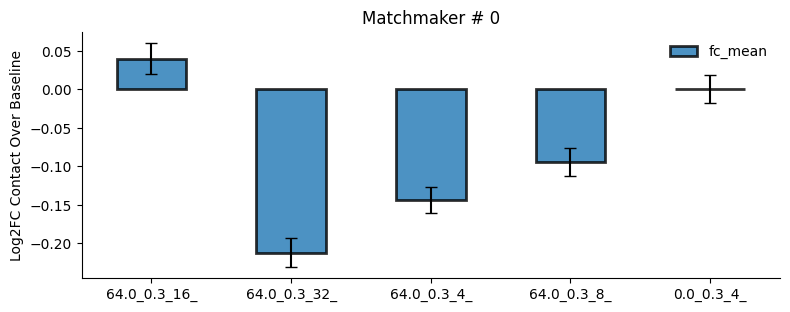

In [204]:
idx = 0
master_df, ftags = parse_data(idx, select, type_to_report='CTCF_other', 
                              report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                             metric='obs')

idx_control=-1

master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
master_df.plot(
        kind='bar',
        y='fc_mean',
        yerr='propagated_se', 
        capsize=4, 
        edgecolor='black',
        alpha=0.8,
        linewidth=2,
    figsize=(8, 3)
    )
    
# Rotate x-labels if they are squished
plt.xticks(rotation=0)
plt.ylabel('Log2FC Contact Over Baseline')
#plt.ylim([-0.75, 0.75])
plt.tight_layout()
#plt.savefig(os.path.join(savedir, f"loop_{loop_idx}_fc.svg"))
plt.title(f"Matchmaker # {idx}")
plt.show()

    Unnamed: 0  left  right  loop_type     MM  loop_idx  obs_mean    obs_se  \
1            1   200    694  CTCF_conv  outer         1  0.161704  0.000796   
12          12   330   1390  CTCF_conv  outer        12  0.003792  0.000106   
23          23  1425   1752  CTCF_conv  outer        23  0.122036  0.000734   

      oe_mean     oe_se  
1   18.044966  0.081624  
12   3.067142  0.081319  
23   6.080297  0.033050  
Unnamed: 0           23
left               1425
right              1752
loop_type     CTCF_conv
MM                outer
loop_idx             23
obs_mean       0.122036
obs_se         0.000734
oe_mean        6.080297
oe_se           0.03305
Name: 23, dtype: object
    Unnamed: 0  left  right  loop_type     MM  loop_idx  obs_mean    obs_se  \
1            1   200    694  CTCF_conv  outer         1  0.150349  0.000897   
12          12   330   1390  CTCF_conv  outer        12  0.004137  0.000104   
23          23  1425   1752  CTCF_conv  outer        23  0.115289  0.000658   

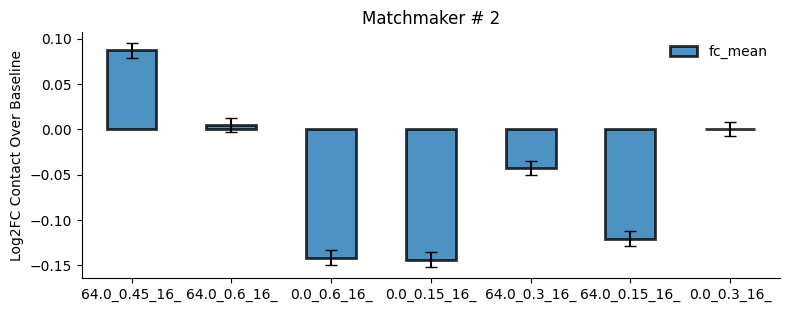

In [168]:
idx = 2
master_df, ftags = parse_data(idx, select, type_to_report='outer', 
                              report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                             metric='obs')

idx_control=-1

master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
master_df.plot(
        kind='bar',
        y='fc_mean',
        yerr='propagated_se', 
        capsize=4, 
        edgecolor='black',
        alpha=0.8,
        linewidth=2,
    figsize=(8, 3)
    )
    
# Rotate x-labels if they are squished
plt.xticks(rotation=0)
plt.ylabel('Log2FC Contact Over Baseline')
#plt.ylim([-0.7, 0.7])
plt.tight_layout()
#plt.savefig(os.path.join(savedir, f"loop_{loop_idx}_fc.svg"))
plt.title(f"Matchmaker # {idx}")
plt.show()